### Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

### Entendimento dos dados

In [2]:
df = pd.read_csv('wine-clustering.csv')

In [3]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [5]:
df.shape

(178, 13)

In [6]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Visualizando os dados

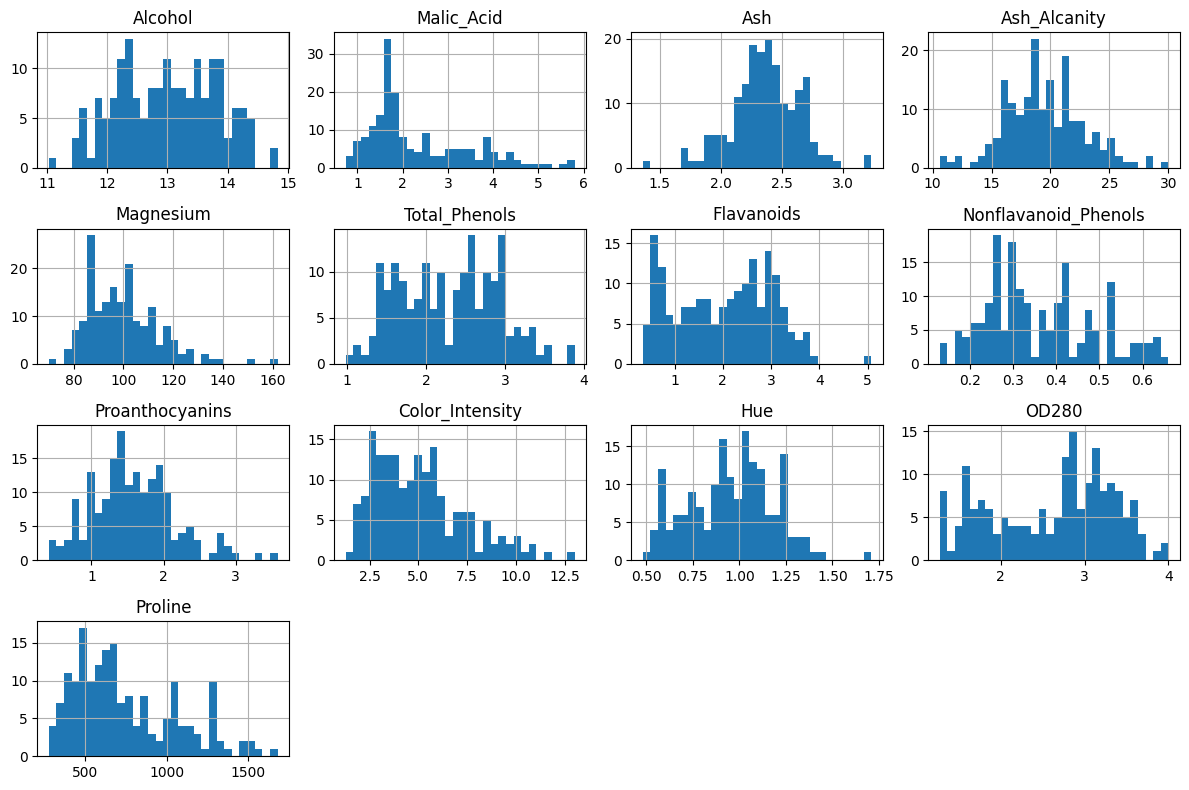

In [7]:
df.hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

In [8]:
df_corr = df.corr()

In [9]:
threshold = 0.5

In [10]:
df_corr = df_corr.where((df_corr >= threshold) & (df_corr != 1))\
                .dropna(how='all', axis=0)\
                .dropna(how='all', axis=1)

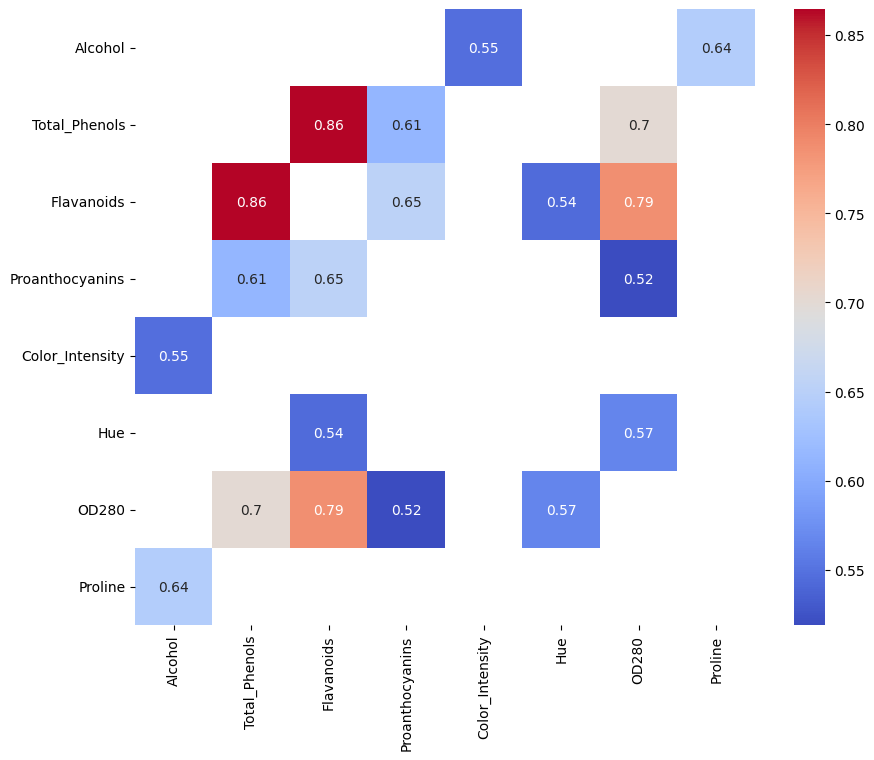

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.show()

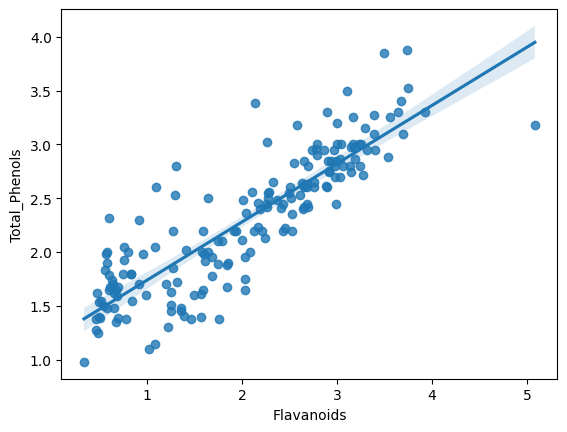

In [12]:
sns.regplot(x='Flavanoids', y='Total_Phenols', data=df)
plt.show()

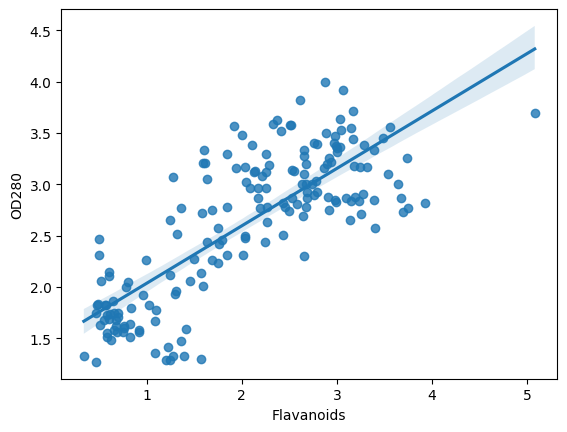

In [13]:
sns.regplot(x='Flavanoids', y= 'OD280', data=df)
plt.show()

In [14]:
df_log = df.copy()

In [15]:
df_log['Proline'] = np.log(df_log['Proline'])

[]

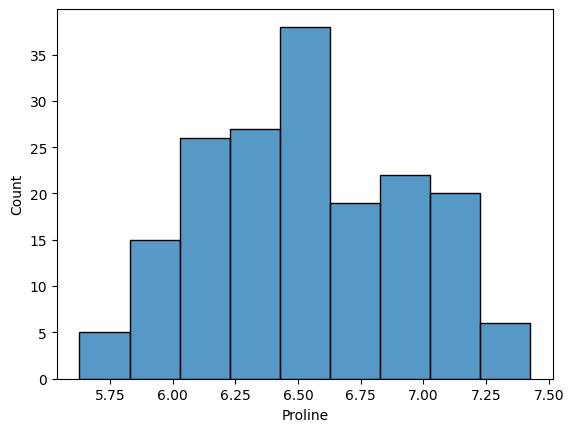

In [16]:
sns.histplot(df_log['Proline'])
plt.plot()

In [17]:
df_log['Magnesium'] = np.log(df_log['Magnesium'])

[]

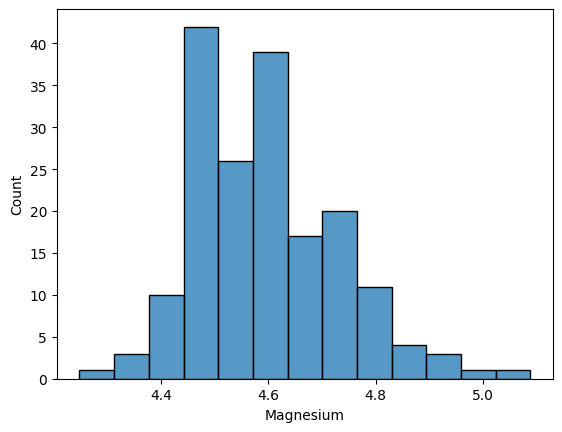

In [18]:
sns.histplot(df_log['Magnesium'])
plt.plot()

### Criação do modelo

In [19]:
scaler = StandardScaler()
df_scaler = pd.DataFrame(scaler.fit_transform(df_log), columns=df_log.columns)

Validando o número de cluster com o Método da Silhueta

In [20]:
K = range(2, 10)

In [21]:
sil_score = []

for i in K:
    km = KMeans(n_clusters= i, n_init=20, random_state=42)
    km.fit(df_scaler)
    sil = silhouette_score(df_scaler, km.labels_)
    sil_score.append(sil)

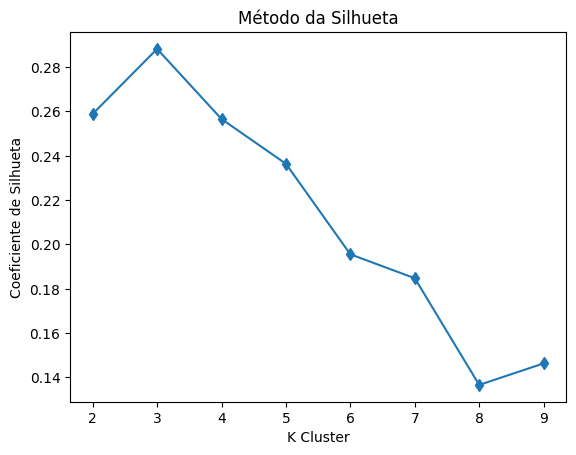

In [22]:
plt.plot(K, sil_score, 'd-')
plt.title('Método da Silhueta')
plt.xlabel('K Cluster')
plt.ylabel('Coeficiente de Silhueta')
plt.show()

Validando o número de cluster com a técnica do cotovelo

In [23]:
sse = []

for i in K:
    km_2 = KMeans(n_clusters=i, n_init=20, random_state=42)
    km_2.fit(df_scaler)
    sse.append(km_2.inertia_)

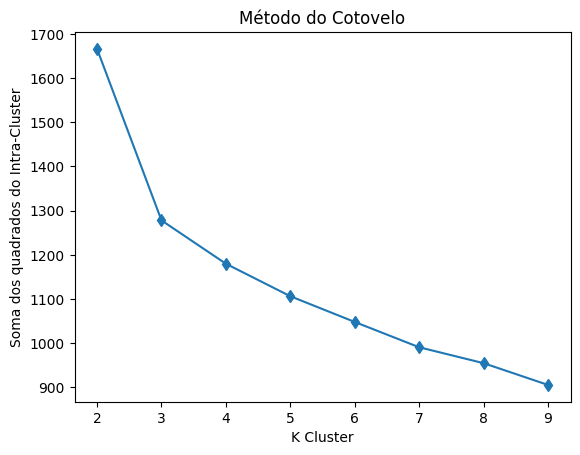

In [24]:
plt.plot(K, sse, 'd-')
plt.title('Método do Cotovelo')
plt.xlabel('K Cluster')
plt.ylabel('Soma dos quadrados do Intra-Cluster')
plt.show()

Nas 2 técnicas para avaliarmos o melhor número de clusters, aponta para 3 cluster sendo o melhor K para este problema 

In [25]:
km_final = KMeans(n_clusters=3, n_init=20, random_state=42)

In [26]:
km_final.fit(df_scaler)

KMeans(n_clusters=3, n_init=20, random_state=42)

In [27]:
df['cluster'] = km_final.predict(df_scaler)

In [28]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


In [29]:
col = df.pop('cluster')
df.insert(0, 'cluster', col)

In [30]:
df[df['cluster'] == 0].mean()

cluster                   0.000000
Alcohol                  12.250923
Malic_Acid                1.897385
Ash                       2.231231
Ash_Alcanity             20.063077
Magnesium                92.738462
Total_Phenols             2.247692
Flavanoids                2.050000
Nonflavanoid_Phenols      0.357692
Proanthocyanins           1.624154
Color_Intensity           2.973077
Hue                       1.062708
OD280                     2.803385
Proline                 510.169231
dtype: float64

In [31]:
df[df['cluster'] == 1].mean()

cluster                   1.000000
Alcohol                  13.134118
Malic_Acid                3.307255
Ash                       2.417647
Ash_Alcanity             21.241176
Magnesium                98.666667
Total_Phenols             1.683922
Flavanoids                0.818824
Nonflavanoid_Phenols      0.451961
Proanthocyanins           1.145882
Color_Intensity           7.234706
Hue                       0.691961
OD280                     1.696667
Proline                 619.058824
dtype: float64

In [32]:
df[df['cluster'] == 2].mean()

cluster                    2.000000
Alcohol                   13.676774
Malic_Acid                 1.997903
Ash                        2.466290
Ash_Alcanity              17.462903
Magnesium                107.967742
Total_Phenols              2.847581
Flavanoids                 3.003226
Nonflavanoid_Phenols       0.292097
Proanthocyanins            1.922097
Color_Intensity            5.453548
Hue                        1.065484
OD280                      3.163387
Proline                 1100.225806
dtype: float64

In [71]:
df.cluster.value_counts()

cluster
0    65
2    62
1    51
Name: count, dtype: int64

In [33]:
pca = PCA(2)

In [44]:
dados_pca = pca.fit_transform(df_scaler)

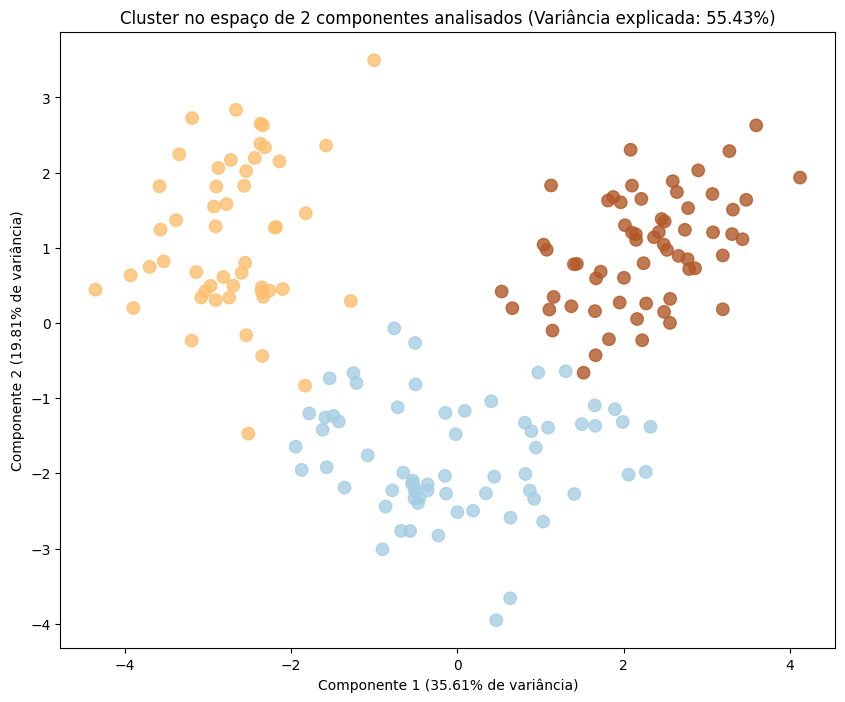

In [70]:
plt.figure(figsize=(10,8))
plt.title(f'Cluster no espaço de 2 componentes analisados (Variância explicada: {pca.explained_variance_ratio_.sum():.2%})')
plt.scatter(
            x=dados_pca[:,0],
            y=dados_pca[:,1],
            c=df['cluster'],
            cmap='Paired',
            s=80,
            alpha=0.8)
plt.xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]:.2%} de variância)')
plt.ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]:.2%} de variância)')
plt.show()